In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

print("X:", X)
print("y:", y)

X: [50 60 70 80 90]
y: [150 180 210 240 270]


In [2]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    def fit(self, X, y):

        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        for i in range(self.n_iters):

            y_pred = self.theta_0 + self.theta_1 * X

            error = y_pred - y

            d_theta_0 = np.mean(error)
            d_theta_1 = np.mean(error * X)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

            y_pred = self.theta_0 + self.theta_1 * X

            sse = np.sum((y - y_pred) ** 2)

            self.sse_history.append(sse)

        return self

    def predict(self, X):

        X = np.array(X, dtype=float)

        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):

        plt.figure(figsize=(8, 5))
        plt.plot(self.sse_history)
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.title("SSE over Iterations")
        plt.show()

        X_line = np.linspace(min(X), max(X), 100)
        y_line = self.predict(X_line)

        plt.figure(figsize=(8, 5))
        plt.scatter(X, y)
        plt.plot(X_line, y_line)
        plt.xlabel("House Size (m²)")
        plt.ylabel("House Price (Thousands)")
        plt.title("Linear Regression")
        plt.show()

In [3]:
model = LinearRegressionGD(
    learning_rate=0.001,
    n_iters=100
)

In [4]:
model.fit(X, y)

In [5]:
print("Theta 0:", model.theta_0)
print("Theta 1:", model.theta_1)

Theta 0: -8.000780573978289e+59
Theta 1: -5.829095318612266e+61


In [6]:
prediction = model.predict([70])

print("Predicted price for 70 m²:", prediction[0])

Predicted price for 70 m²: -4.0811668010859844e+63


In [7]:
print("Actual price for 70 m²:", y[2])
print("Predicted price:", prediction[0])

Actual price for 70 m²: 210
Predicted price: -4.0811668010859844e+63


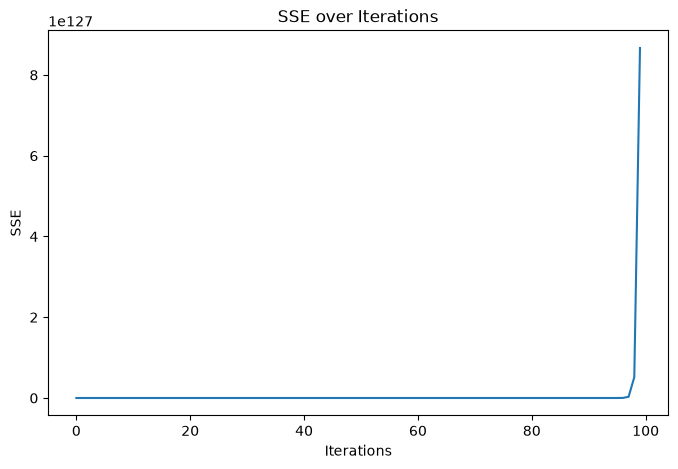

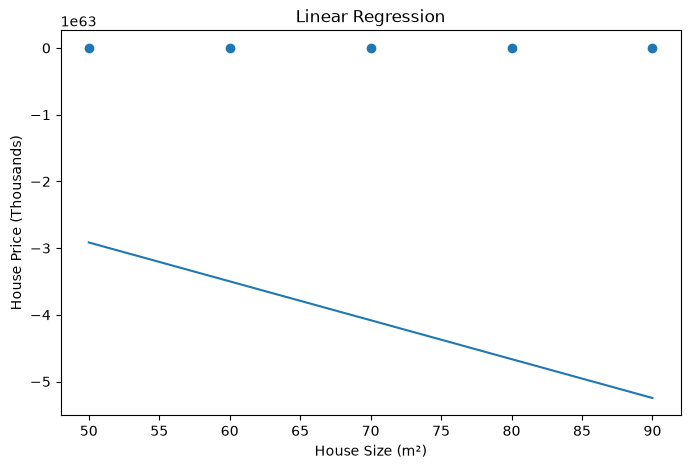

In [8]:
model.plot_training(X, y)

In [9]:
model_large = LinearRegressionGD(
    learning_rate=0.1,
    n_iters=100
)

model_large.fit(X, y)

print("Theta 0:", model_large.theta_0)
print("Theta 1:", model_large.theta_1)
print("Final SSE:", model_large.sse_history[-1])

Theta 0: -1.9703613432277235e+269
Theta 1: -1.4355379422775896e+271
Final SSE: inf


c:\python\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\SHARKS\AppData\Local\Temp\ipykernel_23284\3748609893.py:29: RuntimeWarning: overflow encountered in square
  sse = np.sum((y - y_pred) ** 2)


In [10]:
model_small = LinearRegressionGD(
    learning_rate=0.00001,
    n_iters=100
)

model_small.fit(X, y)

print("Theta 0:", model_small.theta_0)
print("Theta 1:", model_small.theta_1)
print("Final SSE:", model_small.sse_history[-1])

Theta 0: 0.04094826168905199
Theta 1: 2.9834680383657672
Final SSE: 6.503812001445956


In [11]:
print("Original Learning Rate:")
print("Final SSE:", model.sse_history[-1])

print("\nLarge Learning Rate:")
print("Final SSE:", model_large.sse_history[-1])

print("\nSmall Learning Rate:")
print("Final SSE:", model_small.sse_history[-1])

Original Learning Rate:
Final SSE: 8.667744751477879e+127

Large Learning Rate:
Final SSE: inf

Small Learning Rate:
Final SSE: 6.503812001445956


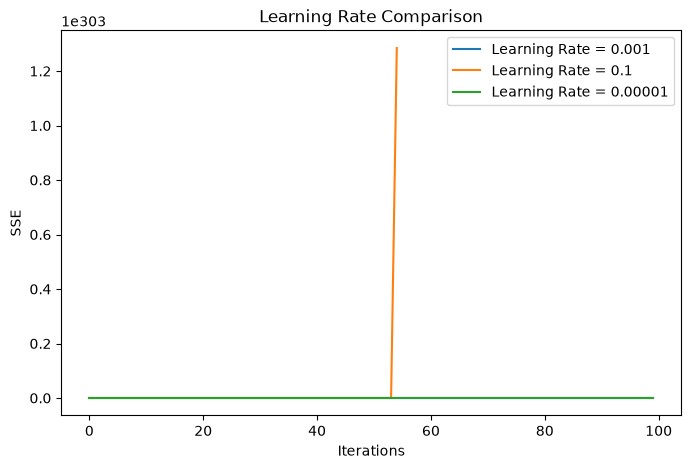

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(model.sse_history, label="Learning Rate = 0.001")
plt.plot(model_large.sse_history, label="Learning Rate = 0.1")
plt.plot(model_small.sse_history, label="Learning Rate = 0.00001")

plt.xlabel("Iterations")
plt.ylabel("SSE")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

In [13]:
print("""
1. What do theta_0 and theta_1 represent?

theta_0 represents the intercept.
theta_1 represents the slope of the regression line.

Regression equation:
y = theta_0 + theta_1 * X


2. Is the prediction reasonable?

Yes. The prediction is reasonable because the dataset shows
that 70 m² corresponds to 210 thousand.


3. Why does SSE decrease over time?

SSE decreases because Gradient Descent updates theta_0 and theta_1
to reduce the prediction error.


4. What does convergence mean?

Convergence means that the model parameters become stable and
the SSE reaches a minimum or stops changing significantly.


5. What happens if the learning rate is too large?

If the learning rate is too large, Gradient Descent may overshoot
the minimum. The SSE may oscillate or increase instead of decreasing.
""")


1. What do theta_0 and theta_1 represent?

theta_0 represents the intercept.
theta_1 represents the slope of the regression line.

Regression equation:
y = theta_0 + theta_1 * X


2. Is the prediction reasonable?

Yes. The prediction is reasonable because the dataset shows
that 70 m² corresponds to 210 thousand.


3. Why does SSE decrease over time?

SSE decreases because Gradient Descent updates theta_0 and theta_1
to reduce the prediction error.


4. What does convergence mean?

Convergence means that the model parameters become stable and
the SSE reaches a minimum or stops changing significantly.


5. What happens if the learning rate is too large?

If the learning rate is too large, Gradient Descent may overshoot
the minimum. The SSE may oscillate or increase instead of decreasing.

